In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from branca.colormap import linear
import geopandas as gpd
import pandas as pd
from DadosAbertosBrasil import ibge
import warnings
warnings.filterwarnings("ignore")

/Users/juliasbardelatti/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df_sim = pd.read_csv("./dados_processados_SIM_filtrado.csv")
df_sim = df_sim[['DTOBITO', 'DTNASC', 'IDADE', 'SEXO', 'RACACOR', 'ESC2010', 'ESC', 'CODMUNRES', 'CAUSABAS']]
df_sim = df_sim.rename(columns={
    "DTOBITO": "data_obito", 
    "DTNASC": "data_nascimento", 
    "IDADE": "idade", 
    "SEXO": "sexo", 
    "RACACOR": "raca_cor", 
    "ESC2010": "escolaridade_2010", 
    "ESC": "escolaridade", 
    "CODMUNRES": "codigo_municipio_ibge",
    "CAUSABAS": "causa_obito"
})
print(len(df_sim))
df_sim['data_obito'] = pd.to_datetime(df_sim['data_obito'])
df_sim['ano_obito'] = df_sim['data_obito'].dt.year
df_sim['codigo_municipio_ibge'] = df_sim['codigo_municipio_ibge'].astype(str)
df_sim['codigo_municipio_ibge_novo'] = df_sim['codigo_municipio_ibge'].str.slice(0, 6)
print(df_sim['ano_obito'].unique())

76233
[2016 2023 2015 2014 2022 2013 2020 2021 2017 2024 2018 2019]


In [4]:
df_sim['data_obito'].max()

Timestamp('2024-12-31 00:00:00')

In [3]:
dados_regioes_uf = {
    'uf': ['AC', 'AL', 'AM', 'BA', 'CE', 'ES', 'GO', 'MA', 'MT', 'MS', 'MG', 
           'PA', 'PB', 'PR', 'PE', 'PI', 'RJ', 'RN', 'RS', 'RO', 'RR', 'SC', 
           'SP', 'SE', 'TO', 'AP', 'DF'],
    'regiao': ['Norte', 'Nordeste', 'Norte', 'Nordeste', 'Nordeste', 'Sudeste', 
               'Centro-Oeste', 'Nordeste', 'Centro-Oeste', 'Centro-Oeste', 'Sudeste', 
               'Norte', 'Nordeste', 'Sul', 'Nordeste', 'Nordeste', 'Sudeste', 
               'Nordeste', 'Sul', 'Norte', 'Norte', 'Sul', 'Sudeste', 'Nordeste', 
               'Norte', 'Norte','Centro-Oeste']
}

df_uf_regioes = pd.DataFrame(dados_regioes_uf)

In [4]:
df_municipios = pd.read_csv("./dados/ibge/municipios.csv", sep=",")
df_estados = pd.read_csv("./dados/ibge/estados.csv", sep=",")

df_municipios = df_municipios.rename(columns={
    "COD UF": "cod_uf", 
    "COD": "codigo_municipio_ibge", 
    "NOME": "nome_municipio"
})
df_municipios['codigo_municipio_ibge'] = df_municipios['codigo_municipio_ibge'].astype(str)
df_municipios['codigo_municipio_ibge_novo'] = df_municipios['codigo_municipio_ibge'].str.slice(0, 6)

df_estados = df_estados.rename(columns={
    "COD": "cod_uf", 
    "NOME": "nome_uf", 
    "SIGLA": "uf"
})
dados_estados_municipios = pd.merge(df_municipios, df_estados, on='cod_uf', how='inner')

dados_estados_municipios['uf'] = dados_estados_municipios['uf'].str.strip()
df_uf_regioes['uf'] = df_uf_regioes['uf'].str.strip()
dados_estados_municipios_regioes = pd.merge(dados_estados_municipios, df_uf_regioes, on='uf', how='inner')

In [5]:
dados_estados_municipios_regioes.to_csv("./dados/ibge/municipios_regioes.csv")

In [6]:
dados_completos = pd.merge(df_sim, dados_estados_municipios_regioes, on='codigo_municipio_ibge_novo', how='inner')
len(dados_completos)

76220

In [16]:
df_sim.query("ano_obito == 2024")

,data_obito,data_nascimento,idade,sexo,raca_cor,escolaridade_2010,escolaridade,codigo_municipio_ibge,causa_obito,ano_obito,codigo_municipio_ibge_novo
56262,2024-02-10,1964-04-20,459,2,1.0,2.0,4.0,430510,C539,2024,430510
56263,2024-08-01,1963-01-01,461,2,5.0,0.0,1.0,140005,C539,2024,140005
56264,2024-02-09,1981-02-13,442,2,1.0,3.0,4.0,292090,C539,2024,292090
56265,2024-01-23,1958-08-16,465,2,4.0,1.0,3.0,230100,C538,2024,230100
56266,2024-03-13,1948-02-10,476,2,4.0,9.0,9.0,250370,C539,2024,250370
...,...,...,...,...,...,...,...,...,...,...,...
63106,2024-11-13,1990-05-18,434,2,1.0,5.0,5.0,530010,C539,2024,530010
63107,2024-11-17,1942-01-30,482,2,4.0,0.0,1.0,521523,C539,2024,521523
63108,2024-12-10,1979-10-04,445,2,1.0,3.0,4.0,530010,C539,2024,530010
63109,2024-11-14,1986-02-28,438,2,4.0,2.0,3.0,520025,C539,2024,520025


### Por população

In [7]:
dados_completos['data_obito'].max()

Timestamp('2024-12-31 00:00:00')

In [8]:
df_agrupado = dados_completos.groupby(['ano_obito','regiao']).size().reset_index()
df_agrupado = df_agrupado.rename(columns={0: 'quantidade_mortes'})
df_populacao_m = pd.read_csv("./dados/ibge/populacao_mulheres_regiao.csv", sep=";", encoding='utf-8')
df_populacao_long = df_populacao_m.melt(id_vars=['regiao'], var_name='ano_obito', value_name='populacao')
df_agrupado['ano_obito'] = df_agrupado['ano_obito'].astype(int)
df_populacao_long['ano_obito'] = df_populacao_long['ano_obito'].astype(int)

df_mortalidade_populacao = pd.merge(df_agrupado, df_populacao_long, on=['ano_obito', 'regiao'], how='left')
df_mortalidade_populacao['taxa_mortalidade'] = (df_mortalidade_populacao['quantidade_mortes'] / df_mortalidade_populacao['populacao']) * 100000
#df_mortalidade_populacao = df_mortalidade_populacao[df_mortalidade_populacao['ano_obito'] < 2024]
df_mortalidade_populacao.to_clipboard(decimal=",")

In [10]:
df_mortalidade_populacao.sort_values(['taxa_mortalidade'], ascending=False)

,ano_obito,regiao,quantidade_mortes,populacao,taxa_mortalidade
47,2022,Norte,940,9152554,10.270357
52,2023,Norte,944,9219590,10.239067
32,2019,Norte,906,8926002,10.150121
22,2017,Norte,879,8744254,10.052315
27,2018,Norte,880,8832449,9.963262
37,2020,Norte,877,9011734,9.731756
57,2024,Norte,894,9287740,9.625592
42,2021,Norte,865,9084053,9.522181
17,2016,Norte,800,8655356,9.242832
12,2015,Norte,782,8558872,9.136718


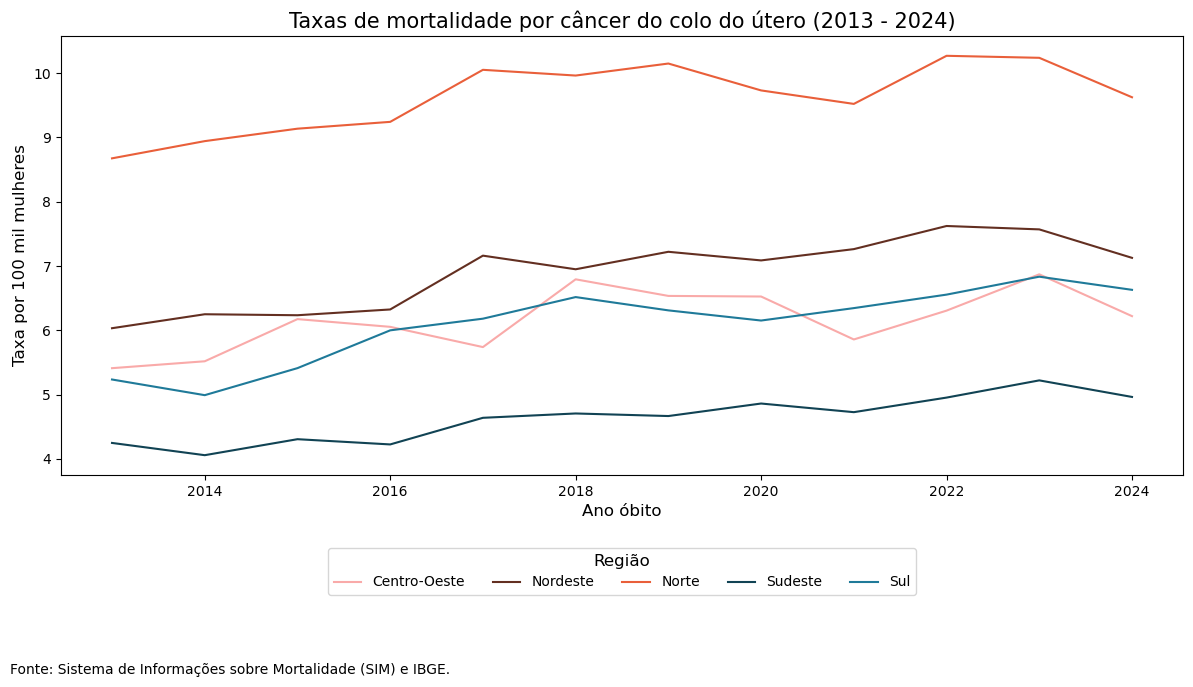

In [20]:
plt.figure(figsize=(12, 7))  
cat_colors = ["#F9AAA9", "#632F21", "#E95F3A", "#114354", "#1F7A99"]
sns.set_palette(cat_colors)

# Plotando todos os anos normalmente (incluindo 2024 agora)
sns.lineplot(data=df_mortalidade_populacao, 
             x='ano_obito', y='taxa_mortalidade', hue='regiao', palette=cat_colors)

plt.title('Taxas de mortalidade por câncer do colo do útero (2013 - 2024)', fontsize=15)
plt.xlabel('Ano óbito', fontsize=12)
plt.ylabel('Taxa por 100 mil mulheres', fontsize=12)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles, labels,
    title='Região',
    title_fontsize='12',
    fontsize='10',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),  # ajusta posição abaixo do eixo x
    ncol=len(labels)  # distribui em uma linha
)

#plt.legend(handles, labels, title='Região', title_fontsize='12', fontsize='10', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(False)

# Removemos a nota de dados parciais
plt.figtext(0.01, -0.02, "Fonte: Sistema de Informações sobre Mortalidade (SIM) e IBGE.", ha="left", fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])  
plt.show()


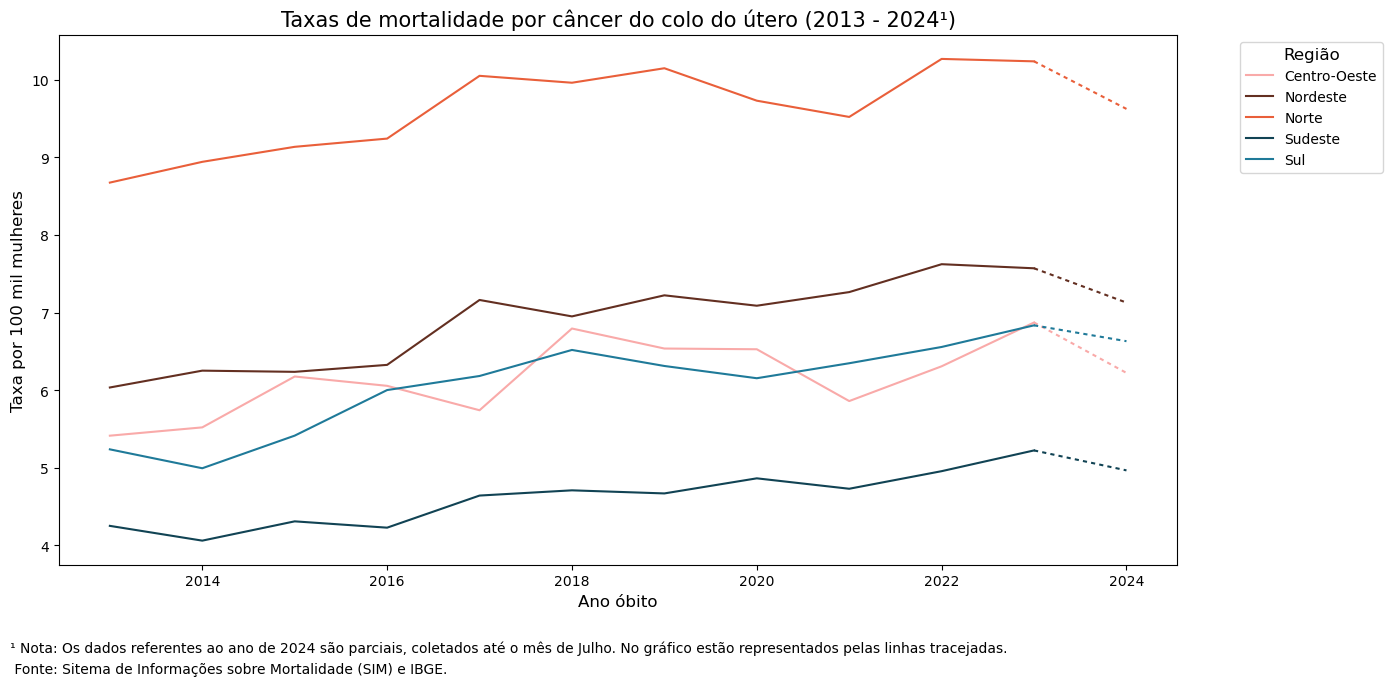

In [21]:
plt.figure(figsize=(14, 7))  
cat_colors = ["#F9AAA9", "#632F21", "#E95F3A", "#114354", "#1F7A99"]
sns.set_palette(cat_colors)

sns.lineplot(data=df_mortalidade_populacao[df_mortalidade_populacao['ano_obito'] < 2024], 
             x='ano_obito', y='taxa_mortalidade', hue='regiao', palette=cat_colors)

for i, regiao in enumerate(df_mortalidade_populacao['regiao'].unique()):
    data_2023_2024 = pd.concat([
        df_mortalidade_populacao[(df_mortalidade_populacao['ano_obito'] == 2023) & (df_mortalidade_populacao['regiao'] == regiao)],
        df_mortalidade_populacao[(df_mortalidade_populacao['ano_obito'] == 2024) & (df_mortalidade_populacao['regiao'] == regiao)]
    ])
    sns.lineplot(data=data_2023_2024, x='ano_obito', y='taxa_mortalidade', color=cat_colors[i], style=True, dashes=[(2, 2)], legend=False)

plt.title('Taxas de mortalidade por câncer do colo do útero (2013 - 2024¹)', fontsize=15)
plt.xlabel('Ano óbito', fontsize=12)
plt.ylabel('Taxa por 100 mil mulheres', fontsize=12)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, title='Região', title_fontsize='12', fontsize='10', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(False)

plt.figtext(0.01, 0.01, "¹ Nota: Os dados referentes ao ano de 2024 são parciais, coletados até o mês de Julho. No gráfico estão representados pelas linhas tracejadas.", ha="left", fontsize=10)
plt.figtext(0.01, -0.02, " Fonte: Sitema de Informações sobre Mortalidade (SIM) e IBGE.", ha="left", fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])  

plt.show()  

In [22]:
df_agrupado = dados_completos
def get_semestre_ano(data):
    ano = data.year
    semestre = 1 if data.month <= 6 else 2
    return f'{semestre}º Semestre - {ano}'

df_agrupado['semestre_ano'] = df_agrupado['data_obito'].apply(get_semestre_ano)
df_casos_semestre_ano = df_agrupado.groupby(['semestre_ano', 'ano_obito','regiao']).size().reset_index(name='quantidade_mortes')
df_primeiro_semestre = df_casos_semestre_ano[df_casos_semestre_ano['semestre_ano'].str.startswith('1')]
df_primeiro_semestre_populacao = pd.merge(df_primeiro_semestre, df_populacao_long, on=['ano_obito', 'regiao'], how='left')
df_primeiro_semestre_populacao['taxa_mortalidade'] = (df_primeiro_semestre_populacao['quantidade_mortes'] / df_primeiro_semestre_populacao['populacao']) * 100000

In [25]:
df_primeiro_semestre_populacao.to_clipboard(decimal=",")

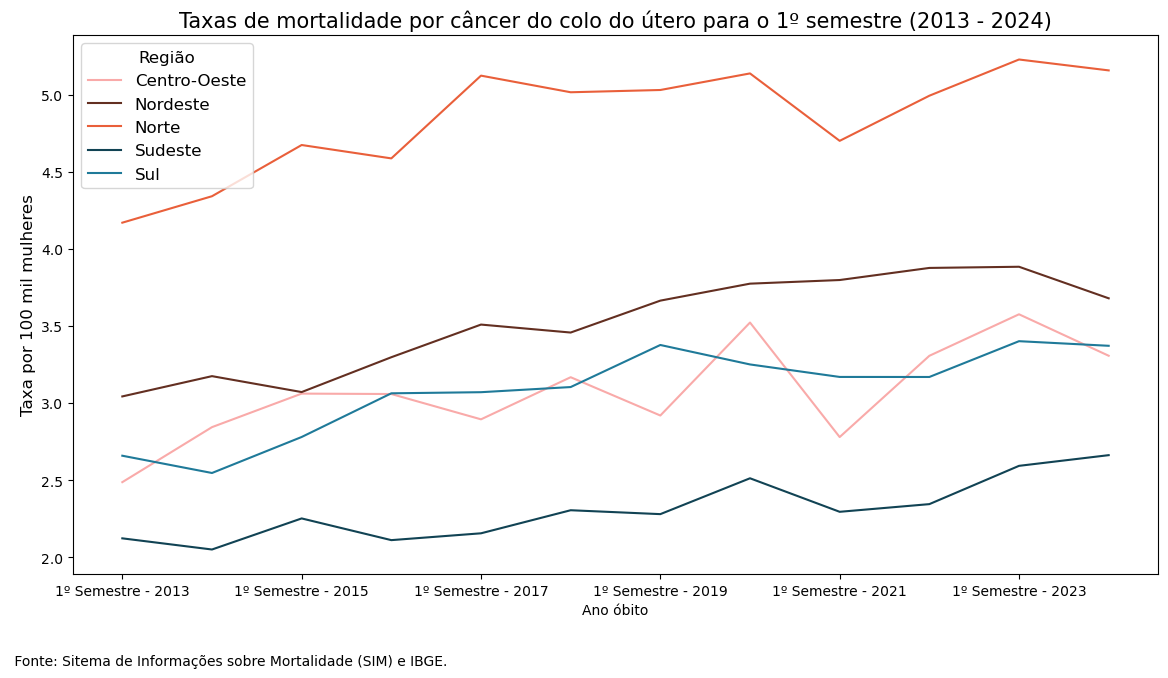

In [23]:
plt.figure(figsize=(14, 7))  
cat_colors = ["#F9AAA9", "#632F21", "#E95F3A", "#114354", "#1F7A99"]
sns.set_palette(cat_colors)
sns.lineplot(data=df_primeiro_semestre_populacao, x='semestre_ano', y='taxa_mortalidade', hue='regiao', palette=cat_colors)
plt.title('Taxas de mortalidade por câncer do colo do útero para o 1º semestre (2013 - 2024)', fontsize=15)
plt.xlabel('Ano óbito', fontsize=10)
plt.ylabel('Taxa por 100 mil mulheres', fontsize=12)
anos_unicos = sorted(df_primeiro_semestre_populacao['semestre_ano'].unique())
anos_selecionados = anos_unicos[::2] 
plt.xticks(anos_selecionados)
plt.legend(title='Região', title_fontsize=12, fontsize=12)
plt.grid(False)
plt.figtext(0.08, -0.02, " Fonte: Sitema de Informações sobre Mortalidade (SIM) e IBGE.", ha="left", fontsize=10)
plt.show()

#### Mortalidade por UF

In [11]:
df_populacao_m = pd.read_excel("./dados/ibge/populacao_ibge_2023_mulheres.xlsx")
df_agrupado = dados_completos.groupby(['ano_obito', 'cod_uf', 'nome_uf']).size().reset_index()
df_agrupado = df_agrupado.rename(columns={0: 'quantidade_mortes'})
df_agrupado = df_agrupado.query("ano_obito == 2024")

In [12]:
df_populacao_m = pd.read_csv("./dados/ibge/mulheres_2024_por_uf.csv", sep=";")
df_agrupado = dados_completos.groupby(['ano_obito', 'cod_uf', 'nome_uf']).size().reset_index()
df_agrupado = df_agrupado.rename(columns={0: 'quantidade_mortes'})
df_agrupado = df_agrupado.query("ano_obito == 2024")

In [13]:
df_mortalidade_populacao = pd.merge(df_agrupado, df_populacao_m, on=['cod_uf'], how='left')
df_mortalidade_populacao['taxa_mortalidade'] = (df_mortalidade_populacao['quantidade_mortes'] / df_mortalidade_populacao['populacao']) * 100000

In [16]:
df_mortalidade_populacao.sort_values(['taxa_mortalidade'], ascending=False)

,ano_obito,cod_uf,nome_uf,quantidade_mortes,populacao,taxa_mortalidade
2,2024,13,Amazonas,274,2129205,12.868653
3,2024,14,Roraima,39,352946,11.049849
1,2024,12,Acre,43,438884,9.797577
7,2024,21,Maranhão,346,3553820,9.736002
8,2024,22,Piauí,161,1724357,9.336814
4,2024,15,Pará,398,4313795,9.226215
6,2024,17,Tocantins,70,783522,8.934018
13,2024,27,Alagoas,140,1667559,8.395505
12,2024,26,Pernambuco,391,4956611,7.888454
5,2024,16,Amapá,31,401255,7.725760


In [29]:
df_mortalidade_populacao.to_clipboard(decimal=",")

In [40]:
geojson_path = ibge.malha(
         nivel = 'paises',
         localidade = 'BR',
         divisoes = 'uf',
         formato = 'geojson'
     )

In [41]:
mapa = folium.Map(location=[-14.2350, -51.9253], zoom_start=4, tiles=None)
colormap = linear.YlOrRd_09.scale(df_mortalidade_populacao["taxa_mortalidade"].min(), df_mortalidade_populacao["taxa_mortalidade"].max())
colormap.caption = 'Taxa mortalidade câncer colo do útero (por 100.000 mulheres)'

folium.Choropleth(
    geo_data=geojson_path,
    data=df_mortalidade_populacao,
    columns=["cod_uf", "taxa_mortalidade"],
    key_on="feature.properties.codarea",
    fill_color="Blues",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Taxa mortalidade câncer colo do útero (por 100.000 mulheres)",
    nan_fill_color="white",
    nan_fill_opacity=0.3
).add_to(mapa)

if isinstance(geojson_path, dict):
    gdf = gpd.GeoDataFrame.from_features(geojson_path["features"])
else:
    gdf = gpd.read_file(geojson_path)  

gdf["codarea"] = gdf["codarea"].astype(int)

for _, row in gdf.iterrows():
    estado_codigo = row["codarea"]
    centroide = row.geometry.centroid  
    taxa_mortalidade = df_mortalidade_populacao.loc[df_mortalidade_populacao["cod_uf"] == estado_codigo, "taxa_mortalidade"]
    
    if not taxa_mortalidade.empty:
        taxa_mortalidade = round(taxa_mortalidade.values[0], 1) 

        folium.Marker(
    location=[centroide.y, centroide.x],
    icon=folium.DivIcon(html=f"""
        <div style="font-size: 12px; font-weight: bold; color: black; 
                    background-color: rgba(255, 255, 255, 0.8); 
                    padding: 3px 7px; border-radius: 5px; 
                    min-width: 35px; text-align: center;">
            {taxa_mortalidade}
        </div>
    """)
).add_to(mapa)
colormap.add_to(mapa)
mapa.get_root().html.add_child(folium.Element("""
    <style>
        .legend {
            font-size: 14px !important;  /* Ajuste o tamanho conforme preferir */
        }
    </style>
"""))

titulo_html = """
    <h3 align="center" style="font-size:16px"><b>
        Taxa de Mortalidade por Câncer do Colo do Útero por Estado (2024)
    </b></h3>
"""
mapa.get_root().html.add_child(folium.Element(titulo_html))
mapa.get_root().html.add_child(folium.Element("""
    <style>
        html, body {
            background-color: white !important;
            height: 100%;
            margin: 0;
        }
        .folium-map { background: white; }
        #map { height: 100%; }
    </style>
"""))
mapa.save("teste.html")

#### Analise mortalidade raça/cor

In [30]:
censo_2022 = pd.read_excel("./dados/ibge/cens_2022.xlsx")

In [31]:
mapeamento_raca = {
    1: "Branca",
    2: "Preta",
    3: "Amarela",
    4: "Parda",
    5: "Indígena"
}

dados_completos['raca_cor'] = dados_completos['raca_cor'].replace(mapeamento_raca)
print("Total óbitos fora da analise por ter raca nulo: ", len(dados_completos[dados_completos["raca_cor"].isna()]))

Total óbitos fora da analise por ter raca nulo:  2078


In [32]:
df_agrupado = dados_completos.groupby(['ano_obito', 'raca_cor']).size().reset_index()
df_agrupado = df_agrupado.rename(columns={0: 'quantidade_mortes'})

In [33]:
dados_completos_censo = pd.merge(df_agrupado, censo_2022, on=['raca_cor'], how='inner')
len(dados_completos_censo)

60

In [34]:
dados_completos_censo['taxa_mortalidade_raca'] = (dados_completos_censo['quantidade_mortes'] / dados_completos_censo['populacao']) * 100000

In [35]:
dados_completos_censo.to_clipboard(decimal=",")

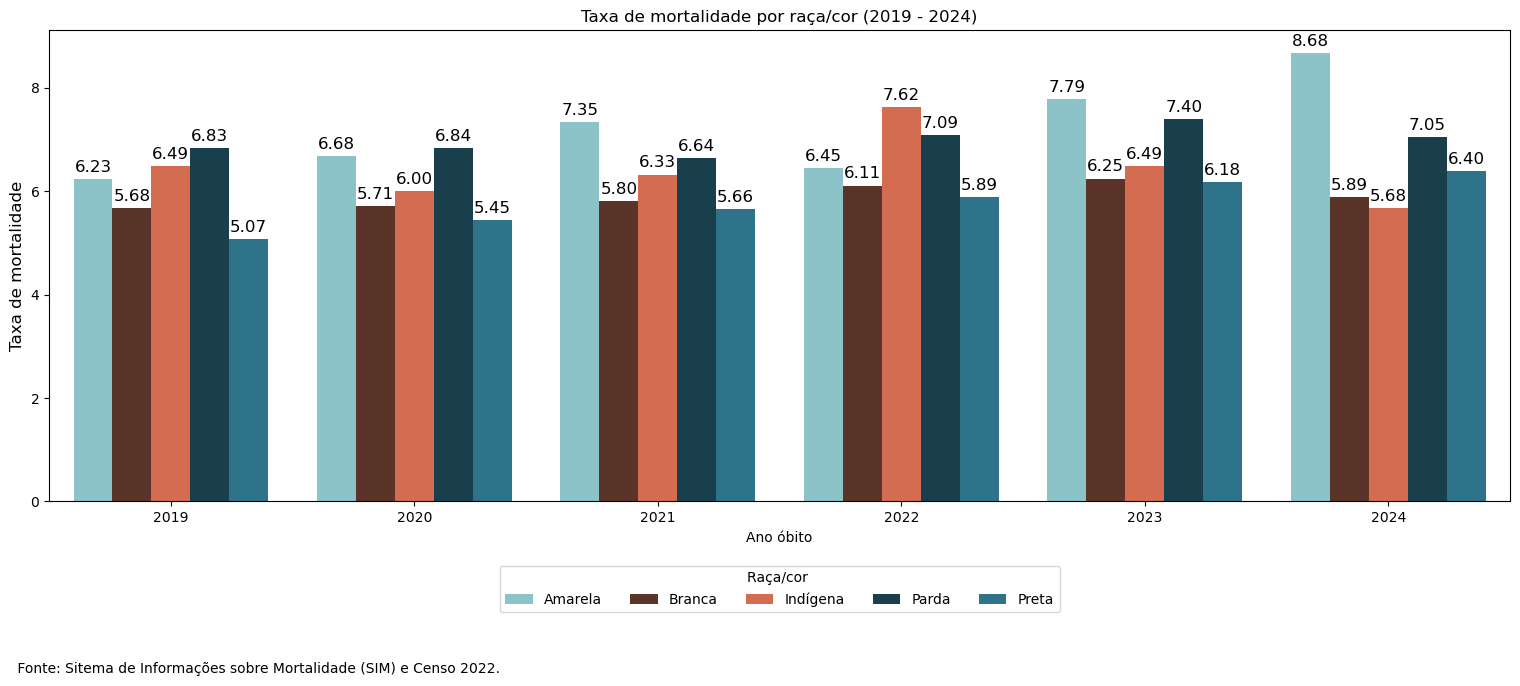

In [47]:
dados_completos_censo_filtro = dados_completos_censo[dados_completos_censo['ano_obito'] > 2018]
cat_colors = ["#81CBD3", "#632F21", "#E95F3A", "#114354", "#1F7A99"]

sns.set_palette(cat_colors)
plt.figure(figsize=(18, 6))
ax = sns.barplot(
    data=dados_completos_censo_filtro,
    x="ano_obito",
    y="taxa_mortalidade_raca",
    hue="raca_cor",
    palette=cat_colors
)
xticks = ax.get_xticks()
xticklabels = [tick.get_text() for tick in ax.get_xticklabels()]
for bar in ax.patches:
    bar_center_x = bar.get_x() + bar.get_width() / 2
    closest_tick_index = min(range(len(xticks)), key=lambda i: abs(xticks[i] - bar_center_x))
    ano_label = int(xticklabels[closest_tick_index])
    if ano_label == 2025:
        bar.set_hatch('///')
        bar.set_edgecolor('white')   
        bar.set_linewidth(1.0)       
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=12)
plt.xlabel("Ano óbito")
plt.legend(title="Raça/cor ", loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=5)
plt.ylabel("Taxa de mortalidade", fontsize=12)
plt.title("Taxa de mortalidade por raça/cor (2019 - 2024)", fontsize=12)
plt.xticks()
plt.grid(False)
plt.figtext(0.01, -0.03, " Fonte: Sitema de Informações sobre Mortalidade (SIM) e Censo 2022.", ha="left", fontsize=10)
plt.tight_layout(rect=[0, 0.05, 0.85, 1.1])  
plt.show()  


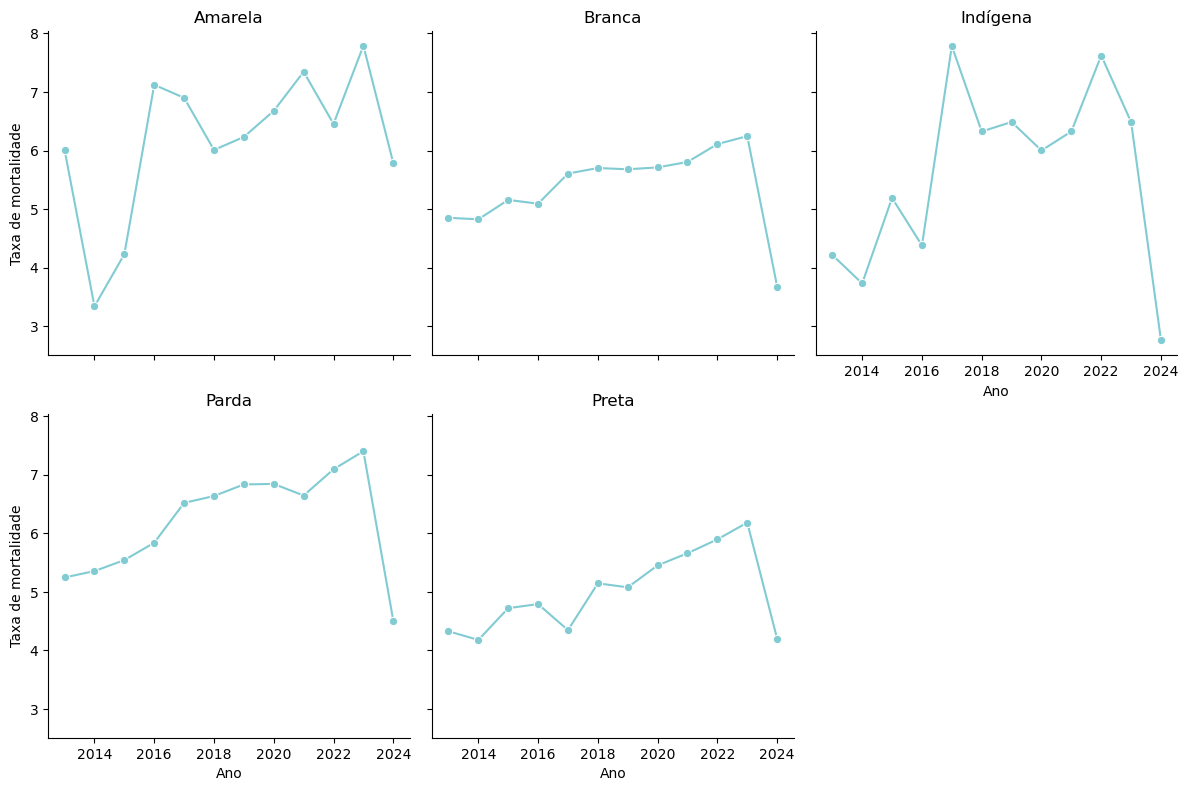

In [25]:
titulo_mapeado = {
    "1": "Branca",
    "2": "Preta",
    "3": "Parda",
    "4": "Amarela",
    "5": "Indígena"
}

g = sns.FacetGrid(dados_completos_censo, col="raca_cor", col_wrap=3, height=4, sharey=True)
g.map(sns.lineplot, "ano_obito", "taxa_mortalidade_raca", marker="o")
g.set_axis_labels("Ano", "Taxa de mortalidade")

g.set_titles(col_template="{col_name}")
for ax in g.axes.flat:
    titulo_original = ax.get_title()
    ax.set_title(titulo_mapeado.get(titulo_original, titulo_original))

plt.show()
